In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [3]:
dataframe = pd.read_csv(r'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\GAME_OVER.csv')

In [5]:
dataframe

,GameSeed,GameName,Round,Event,Tick,Turn,PlayerCount,GameID,OrdinalPosition(Player-1 rank),OrdinalPosition(PlayerName-0),...,RuleCardsUsed(Rule-PushOut),RuleCardsUsed(Rule-PushRequirement),RuleCardsUsed(Rule-Victory),PlayerType(PlayerType-1),PlayerType(PlayerType-0),MarbelsRemoved(Player0removed marbles),MarbelsRemoved(Player1removed marbles),WhoPushedOut(Player0Pushed Marbles),WhoPushedOut(Player1Pushed Marbles),Winner(PlayerIdx)
0,1746059027,MultiverseMarbles,0,GAME_OVER,109,108,2,2,2,Recommended_4,...,"Pushed out marbles return to the center, if it...",You can push your opposing marbles if you use ...,Push out 3 opposing marbles.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[],[0],[],"[1, 0, 0, 0]",0
1,1717405991,MultiverseMarbles,0,GAME_OVER,98,97,2,3,1,Recommended_4,...,Pushed out marbles are removed from play,You can push opposing marbles if you use more ...,Occupy all goals of your color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,"[0, 0, 0]",[],"[0, 0, 0]",[],1
2,-815598253,MultiverseMarbles,0,GAME_OVER,73,72,2,4,2,Recommended_4,...,Pushed out marbles return to the center. Remov...,You can push your opposing marbles if you use ...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[],[],"[0, 0]",[],0
3,2110276287,MultiverseMarbles,0,GAME_OVER,34,33,2,5,1,Recommended_4,...,Pushed out marbles are removed from play,You can push opposing marbles if you use fewer...,Occupy 3 non-neighbouring goals.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[0],[],[0],[],1
4,-2066950591,MultiverseMarbles,0,GAME_OVER,21,20,2,6,2,Recommended_4,...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use equal...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4,[],[],[],[],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,-1791427606,MultiverseMarbles,0,GAME_OVER,27,26,2,993,2,Recommended_4_pushVictoryHeuristic,...,Pushed out marbles are removed from play,You can push opposing marbles if you use an ev...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],"[0, 0]",[],"[0, 0]",0
992,1363510825,MultiverseMarbles,0,GAME_OVER,83,82,2,994,2,Recommended_4_pushVictoryHeuristic,...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use fewer...,Occupy 1 goal of each color.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],[],[],[],0
993,33308118,MultiverseMarbles,0,GAME_OVER,193,192,2,995,2,Recommended_4_pushVictoryHeuristic,...,"Pushed out marbles return to the center, if it...",You can push your opposing marbles if you use ...,Occupy 3 non-neighbouring goals.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],[],[],"[1, 0]",0
994,-1891042671,MultiverseMarbles,0,GAME_OVER,28,27,2,996,1,Recommended_4_pushVictoryHeuristic,...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use an ev...,Occupy 3 non-neighbouring goals.,Recommended_4_ownColorVictoryHeuristic,Recommended_4_pushVictoryHeuristic,[],[],[],[1],1


In [7]:
# Calculate win rates for each player by rule-victory type
# First, let's identify player name columns and create a more structured dataset

# Step 1: Create a dataframe with player names, whether they won, and the rule-victory type
player_results = []

# Process player 0
player_results.append(pd.DataFrame({
    'PlayerName': dataframe['OrdinalPosition(PlayerName-0)'],
    'Won': dataframe['Winner(PlayerIdx)'] == 0,  # True if this player won
    'RuleVictory': dataframe['RuleCardsUsed(Rule-Victory)']
}))

# Process player 1
player_results.append(pd.DataFrame({
    'PlayerName': dataframe['OrdinalPosition(PlayerName-1)'],
    'Won': dataframe['Winner(PlayerIdx)'] == 1,  # True if this player won
    'RuleVictory': dataframe['RuleCardsUsed(Rule-Victory)']
}))

# Combine into one dataframe
all_results = pd.concat(player_results, ignore_index=True)

# Step 2: Calculate win rates by player and rule-victory
# Group by player name and rule-victory, then calculate mean of 'Won' (True=1, False=0)
win_rates_victory = all_results.groupby(['PlayerName', 'RuleVictory'])['Won'].agg(['sum', 'count'])
win_rates_victory['win_rate'] = win_rates_victory['sum'] / win_rates_victory['count']

# Reset index for better display
win_rates_victory = win_rates_victory.reset_index()

# Rename columns for clarity
win_rates_victory.columns = ['PlayerName', 'RuleVictory', 'Wins', 'Games', 'WinRate']

# Sort by win rate in descending order
win_rates_victory = win_rates_victory.sort_values(by=['RuleVictory', 'WinRate'], ascending=[True, False])

# Display the results
print(win_rates_victory)

                                PlayerName                       RuleVictory  \
4   Recommended_4_ownColorVictoryHeuristic      Occupy 1 goal of each color.   
8       Recommended_4_pushVictoryHeuristic      Occupy 1 goal of each color.   
0                            Recommended_4      Occupy 1 goal of each color.   
5   Recommended_4_ownColorVictoryHeuristic  Occupy 3 non-neighbouring goals.   
1                            Recommended_4  Occupy 3 non-neighbouring goals.   
9       Recommended_4_pushVictoryHeuristic  Occupy 3 non-neighbouring goals.   
6   Recommended_4_ownColorVictoryHeuristic   Occupy all goals of your color.   
10      Recommended_4_pushVictoryHeuristic   Occupy all goals of your color.   
2                            Recommended_4   Occupy all goals of your color.   
11      Recommended_4_pushVictoryHeuristic      Push out 3 opposing marbles.   
7   Recommended_4_ownColorVictoryHeuristic      Push out 3 opposing marbles.   
3                            Recommended

In [9]:

# Assuming the dataframe is named 'dataframe'
# First, let's create a list to store player data with win/loss information
player_results = []

# Process each game to extract player results
for _, row in dataframe.iterrows():
    # Determine the winner (0 or 1)
    winner_idx = row['Winner(PlayerIdx)']
    
    # Extract rule combinations
    rule_setup = row['RuleCardsUsed(Rule-Setup)']
    rule_movement = row['RuleCardsUsed(Rule-Movement)']
    rule_push = row['RuleCardsUsed(Rule-Push)']
    rule_pushout = row['RuleCardsUsed(Rule-PushOut)']
    rule_pushrequirement = row['RuleCardsUsed(Rule-PushRequirement)']
    rule_victory = row['RuleCardsUsed(Rule-Victory)']
    
    # Create a rule combination identifier
    rule_combo = (rule_setup, rule_movement, rule_push, rule_pushout, rule_pushrequirement, rule_victory)
    
    # Add Player0 data
    player0_name = row['OrdinalPosition(PlayerName-0)']
    player0_won = 1 if winner_idx == 0 else 0
    player_results.append({
        'Player_Name': player0_name,
        'Rule_Setup': rule_setup,
        'Rule_Movement': rule_movement,
        'Rule_Push': rule_push,
        'Rule_PushOut': rule_pushout,
        'Rule_PushRequirement': rule_pushrequirement,
        'Rule_Victory': rule_victory,
        'Rule_Combo': str(rule_combo),  # Convert tuple to string for grouping
        'Won': player0_won
    })
    
    # Add Player1 data
    player1_name = row['OrdinalPosition(PlayerName-1)']
    player1_won = 1 if winner_idx == 1 else 0
    player_results.append({
        'Player_Name': player1_name,
        'Rule_Setup': rule_setup,
        'Rule_Movement': rule_movement,
        'Rule_Push': rule_push,
        'Rule_PushOut': rule_pushout,
        'Rule_PushRequirement': rule_pushrequirement,
        'Rule_Victory': rule_victory,
        'Rule_Combo': str(rule_combo),  # Convert tuple to string for grouping
        'Won': player1_won
    })

# Convert to DataFrame
results_df = pd.DataFrame(player_results)

# Calculate win rates by player and rule combination
win_rates_setup = results_df.groupby(['Player_Name', 'Rule_Combo']).agg({
    'Won': ['mean', 'sum', 'count']  # mean = win rate, sum = wins, count = total games
}).reset_index()

# Flatten the multi-level columns
win_rates_setup.columns = ['Player_Name', 'Rule_Combo', 'Win_Rate', 'Wins', 'Games_Played']

# Extract individual rule components back from the combo string
# This is a bit hacky but works for display purposes
win_rates_setup[['Rule_Setup', 'Rule_Movement', 'Rule_Push', 'Rule_PushOut', 
           'Rule_PushRequirement', 'Rule_Victory']] = results_df.groupby(['Player_Name', 'Rule_Combo']).first()[
    ['Rule_Setup', 'Rule_Movement', 'Rule_Push', 'Rule_PushOut', 
     'Rule_PushRequirement', 'Rule_Victory']
].reset_index(drop=True)

# Drop the combined rule column as we now have individual columns
win_rates_setup = win_rates_setup.drop('Rule_Combo', axis=1)

# Reorder columns for better readability
win_rates_setup = win_rates_setup[['Player_Name', 'Win_Rate', 'Wins', 'Games_Played',
                       'Rule_Setup', 'Rule_Movement', 'Rule_Push', 'Rule_PushOut', 
                       'Rule_PushRequirement', 'Rule_Victory']]

# Sort by player name and win rate (descending)
win_rates_setup = win_rates_setup.sort_values(['Player_Name', 'Win_Rate'], ascending=[True, False])

# Display the results
win_rates_setup

,Player_Name,Win_Rate,Wins,Games_Played,Rule_Setup,Rule_Movement,Rule_Push,Rule_PushOut,Rule_PushRequirement,Rule_Victory
93,Recommended_4,1.0,4,4,TwoSides.txt,Move 1 marble by up to 3 spaces in any directi...,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use more ...,Occupy 3 non-neighbouring goals.
110,Recommended_4,1.0,4,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,"Pushed out marbles return to the center, if it...",You can push opposing marbles if you use an ev...,Occupy all goals of your color.
123,Recommended_4,1.0,4,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use an ev...,Occupy 3 non-neighbouring goals.
125,Recommended_4,1.0,4,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use fewer...,Occupy all goals of your color.
129,Recommended_4,1.0,4,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use more ...,Occupy 1 goal of each color.
...,...,...,...,...,...,...,...,...,...,...
387,Recommended_4_pushVictoryHeuristic,0.0,0,8,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,"Pushed out marbles return to the center, if it...",You can push opposing marbles if you use more ...,Occupy all goals of your color.
389,Recommended_4_pushVictoryHeuristic,0.0,0,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,"Pushed out marbles return to the center, if it...",You can push opposing marbles if you use more ...,Occupy all goals of your color.
393,Recommended_4_pushVictoryHeuristic,0.0,0,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use an ev...,Occupy 3 non-neighbouring goals.
395,Recommended_4_pushVictoryHeuristic,0.0,0,4,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use fewer...,Occupy all goals of your color.


In [11]:

# Assuming the dataframe is named 'dataframe'
# Convert string representations of lists to actual lists more safely
def convert_to_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)  # Safer than eval
        except (ValueError, SyntaxError):
            return []
    return x if isinstance(x, list) else []

# Check column names in the dataframe
print("Available columns:", dataframe.columns.tolist())

# Define the expected column names
expected_columns = {
    'removed_p0': 'MarbelsRemoved(Player0removed marbles)',
    'removed_p1': 'MarbelsRemoved(Player1removed marbles)',
    'pushed_p0': 'WhoPushedOut(Player0Pushed Marbles)',
    'pushed_p1': 'WhoPushedOut(Player1Pushed Marbles)'
}

# Check if columns exist and create a mapping to actual column names
column_mapping = {}
for key, expected_name in expected_columns.items():
    # Try to find the exact column name
    if expected_name in dataframe.columns:
        column_mapping[key] = expected_name
    else:
        # Try to find a similar column name (case insensitive, ignoring spaces)
        for col in dataframe.columns:
            if expected_name.lower().replace(' ', '') in col.lower().replace(' ', ''):
                column_mapping[key] = col
                print(f"Found similar column: '{col}' for '{expected_name}'")
                break
        else:
            print(f"Warning: Could not find column similar to '{expected_name}'")
            # Create an empty column as fallback
            dataframe[expected_name] = [[] for _ in range(len(dataframe))]
            column_mapping[key] = expected_name

# Apply conversion to the columns that exist
for key, col_name in column_mapping.items():
    dataframe[col_name] = dataframe[col_name].apply(convert_to_list)

# Calculate the number of marbles pushed out and removed for each player
dataframe['Player0_PushedMarbles_Count'] = dataframe[column_mapping['pushed_p0']].apply(lambda x: len(x) if isinstance(x, list) else 0)
dataframe['Player1_PushedMarbles_Count'] = dataframe[column_mapping['pushed_p1']].apply(lambda x: len(x) if isinstance(x, list) else 0)
dataframe['Player0_RemovedMarbles_Count'] = dataframe[column_mapping['removed_p0']].apply(lambda x: len(x) if isinstance(x, list) else 0)
dataframe['Player1_RemovedMarbles_Count'] = dataframe[column_mapping['removed_p1']].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Calculate the ratios (pushed marbles / total starting marbles)
dataframe['Player0_PushedMarbles_Ratio'] = dataframe['Player0_PushedMarbles_Count'] / 10
dataframe['Player1_PushedMarbles_Ratio'] = dataframe['Player1_PushedMarbles_Count'] / 10

# Calculate the ratios (removed marbles / total starting marbles)
dataframe['Player0_RemovedMarbles_Ratio'] = dataframe['Player0_RemovedMarbles_Count'] / 10
dataframe['Player1_RemovedMarbles_Ratio'] = dataframe['Player1_RemovedMarbles_Count'] / 10

# Check if required columns for grouping exist
required_columns = ['OrdinalPosition(PlayerName-0)', 'OrdinalPosition(PlayerName-1)', 'RuleCardsUsed(Rule-Victory)']
missing_cols = [col for col in required_columns if col not in dataframe.columns]

if not missing_cols:
    # Group by player names and victory condition to get average ratios
    marbles_per_victory = dataframe.groupby(['OrdinalPosition(PlayerName-0)', 'OrdinalPosition(PlayerName-1)', 
                            'RuleCardsUsed(Rule-Victory)'])[
        ['Player0_PushedMarbles_Ratio', 'Player1_PushedMarbles_Ratio',
        'Player0_RemovedMarbles_Ratio', 'Player1_RemovedMarbles_Ratio']
    ].mean().reset_index()

    # Rename columns for clarity
    marbles_per_victory = marbles_per_victory.rename(columns={
        'OrdinalPosition(PlayerName-0)': 'Player0_Name',
        'OrdinalPosition(PlayerName-1)': 'Player1_Name',
        'RuleCardsUsed(Rule-Victory)': 'Victory_Condition',
        'Player0_PushedMarbles_Ratio': 'Player0_PushedMarbles_Ratio_Avg',
        'Player1_PushedMarbles_Ratio': 'Player1_PushedMarbles_Ratio_Avg',
        'Player0_RemovedMarbles_Ratio': 'Player0_RemovedMarbles_Ratio_Avg',
        'Player1_RemovedMarbles_Ratio': 'Player1_RemovedMarbles_Ratio_Avg'
    })

    # Display the results
    print(marbles_per_victory)
else:
    print(f"Missing required columns for grouping: {missing_cols}")

Available columns: ['GameSeed', 'GameName', 'Round', 'Event', 'Tick', 'Turn', 'PlayerCount', 'GameID', 'OrdinalPosition(Player-1 rank)', 'OrdinalPosition(PlayerName-0)', 'OrdinalPosition(Player-1)', 'OrdinalPosition(Player-0)', 'OrdinalPosition(Player-0 rank)', 'OrdinalPosition(PlayerName-1)', 'FinalScore(PlayerName-0)', 'FinalScore(Player-1)', 'FinalScore(Player-0)', 'FinalScore(PlayerName-1)', 'MarbelsPerPlayer(Player1Remaining Marbles)', 'MarbelsPerPlayer(Player0Remaining Marbles)', 'RuleCardsUsed(Rule-Setup)', 'RuleCardsUsed(Rule-Movement)', 'RuleCardsUsed(Rule-Push)', 'RuleCardsUsed(Rule-PushOut)', 'RuleCardsUsed(Rule-PushRequirement)', 'RuleCardsUsed(Rule-Victory)', 'PlayerType(PlayerType-1)', 'PlayerType(PlayerType-0)', 'MarbelsRemoved(Player0removed marbles)', 'MarbelsRemoved(Player1removed marbles)', 'WhoPushedOut(Player0Pushed Marbles)', 'WhoPushedOut(Player1Pushed Marbles)', 'Winner(PlayerIdx)']
                              Player0_Name  \
0                            Recom

In [13]:

# Assuming the dataframe is named 'dataframe'
# Convert string representations of lists to actual lists if needed
def convert_to_list(x):
    if isinstance(x, str):
        return eval(x)  # Converts string representation of list to actual list
    return x

# Apply conversion to the relevant columns
dataframe['MarbelsRemoved(Player0removed marbles)'] = dataframe['MarbelsRemoved(Player0removed marbles)'].apply(convert_to_list)
dataframe['MarbelsRemoved(Player1removed marbles)'] = dataframe['MarbelsRemoved(Player1removed marbles)'].apply(convert_to_list)
dataframe['WhoPushedOut(Player0Pushed Marbles)'] = dataframe['WhoPushedOut(Player0Pushed Marbles)'].apply(convert_to_list)
dataframe['WhoPushedOut(Player1Pushed Marbles)'] = dataframe['WhoPushedOut(Player1Pushed Marbles)'].apply(convert_to_list)

# Calculate the number of marbles pushed out for each player (length of the list)
dataframe['Player0_PushedMarbles_Count'] = dataframe['WhoPushedOut(Player0Pushed Marbles)'].apply(len)
dataframe['Player1_PushedMarbles_Count'] = dataframe['WhoPushedOut(Player1Pushed Marbles)'].apply(len)

# Calculate the number of marbles removed for each player
dataframe['Player0_RemovedMarbles_Count'] = dataframe['MarbelsRemoved(Player0removed marbles)'].apply(len)
dataframe['Player1_RemovedMarbles_Count'] = dataframe['MarbelsRemoved(Player1removed marbles)'].apply(len)

# Calculate the ratios (pushed marbles / total starting marbles)
dataframe['Player0_PushedMarbles_Ratio'] = dataframe['Player0_PushedMarbles_Count'] / 10
dataframe['Player1_PushedMarbles_Ratio'] = dataframe['Player1_PushedMarbles_Count'] / 10

# Calculate the ratios (removed marbles / total starting marbles)
dataframe['Player0_RemovedMarbles_Ratio'] = dataframe['Player0_RemovedMarbles_Count'] / 10
dataframe['Player1_RemovedMarbles_Ratio'] = dataframe['Player1_RemovedMarbles_Count'] / 10

# Group by all rule combinations to get average ratios
marbles_per_setup = dataframe.groupby([
    'RuleCardsUsed(Rule-Setup)',
    'RuleCardsUsed(Rule-Movement)',
    'RuleCardsUsed(Rule-Push)',
    'RuleCardsUsed(Rule-PushOut)',
    'RuleCardsUsed(Rule-PushRequirement)',
    'RuleCardsUsed(Rule-Victory)'
])[
    ['Player0_PushedMarbles_Ratio', 'Player1_PushedMarbles_Ratio',
     'Player0_RemovedMarbles_Ratio', 'Player1_RemovedMarbles_Ratio']
].mean().reset_index()

# Rename columns for clarity
marbles_per_setup = marbles_per_setup.rename(columns={
    'RuleCardsUsed(Rule-Setup)': 'Setup_Rule',
    'RuleCardsUsed(Rule-Movement)': 'Movement_Rule',
    'RuleCardsUsed(Rule-Push)': 'Push_Rule',
    'RuleCardsUsed(Rule-PushOut)': 'PushOut_Rule',
    'RuleCardsUsed(Rule-PushRequirement)': 'PushRequirement_Rule',
    'RuleCardsUsed(Rule-Victory)': 'Victory_Rule',
    'Player0_PushedMarbles_Ratio': 'Player0_PushedMarbles_Ratio_Avg',
    'Player1_PushedMarbles_Ratio': 'Player1_PushedMarbles_Ratio_Avg',
    'Player0_RemovedMarbles_Ratio': 'Player0_RemovedMarbles_Ratio_Avg',
    'Player1_RemovedMarbles_Ratio': 'Player1_RemovedMarbles_Ratio_Avg'
})

# Add a total pushed and removed ratio column for easier comparison
marbles_per_setup['Total_PushedMarbles_Ratio_Avg'] = (marbles_per_setup['Player0_PushedMarbles_Ratio_Avg'] + 
                                          marbles_per_setup['Player1_PushedMarbles_Ratio_Avg']) / 2
marbles_per_setup['Total_RemovedMarbles_Ratio_Avg'] = (marbles_per_setup['Player0_RemovedMarbles_Ratio_Avg'] + 
                                           marbles_per_setup['Player1_RemovedMarbles_Ratio_Avg']) / 2

# Sort by total pushed marbles ratio to see which rule combinations lead to more aggressive play
marbles_per_setup = marbles_per_setup.sort_values('Total_PushedMarbles_Ratio_Avg', ascending=False)

# Display the results
marbles_per_setup

,Setup_Rule,Movement_Rule,Push_Rule,PushOut_Rule,PushRequirement_Rule,Victory_Rule,Player0_PushedMarbles_Ratio_Avg,Player1_PushedMarbles_Ratio_Avg,Player0_RemovedMarbles_Ratio_Avg,Player1_RemovedMarbles_Ratio_Avg,Total_PushedMarbles_Ratio_Avg,Total_RemovedMarbles_Ratio_Avg
130,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use more ...,Occupy all goals of your color.,0.316667,0.350000,0.183333,0.150000,0.333333,0.166667
126,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use fewer...,Push out 3 opposing marbles.,0.300000,0.283333,0.150000,0.216667,0.291667,0.183333
41,TwoSides.txt,Move 1 marble by 1 space in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles are removed from play,You can push opposing marbles if you use more ...,Occupy all goals of your color.,0.333333,0.225000,0.333333,0.225000,0.279167,0.279167
49,TwoSides.txt,Move 1 marble by 1 space in any direction.,Push a column of marbles by 1 space in any dir...,"Pushed out marbles return to the center, if it...",You can push opposing marbles if you use fewer...,Push out 3 opposing marbles.,0.333333,0.216667,0.250000,0.150000,0.275000,0.200000
83,TwoSides.txt,Move 1 marble by up to 3 spaces in any directi...,Push a column of marbles by 1 space in any dir...,"Pushed out marbles return to the center, if it...",You can push opposing marbles if you use more ...,Push out 3 opposing marbles.,0.283333,0.266667,0.133333,0.116667,0.275000,0.125000
...,...,...,...,...,...,...,...,...,...,...,...,...
52,TwoSides.txt,Move 1 marble by 1 space in any direction.,Push a column of marbles by 1 space in any dir...,Pushed out marbles return to the center. Remov...,You can push opposing marbles if you use fewer...,Occupy 1 goal of each color.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,TwoSides.txt,Jump over 1 marble or blocker or move a marble...,Push a column of marbles by 1 space in any dir...,Pushed out marbles are removed from play,You can push opposing marbles if you use equal...,Occupy 1 goal of each color.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
64,TwoSides.txt,Move 1 marble by up to 3 spaces in any directi...,Push a column of marbles by 1 space in any dir...,Pushed out marbles are removed from play,You can push opposing marbles if you use equal...,Occupy 3 non-neighbouring goals.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
113,TwoSides.txt,Move 1 marble exactly 2 spaces in any direction.,Push a column of marbles by 1 space in any dir...,"Pushed out marbles return to the center, if it...",You can push opposing marbles if you use fewer...,Occupy 1 goal of each color.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
# Assuming the dataframe is named 'dataframe'
# Convert string representations of lists to actual lists if needed
def convert_to_list(x):
    if isinstance(x, str):
        return eval(x)  # Converts string representation of list to actual list
    return x

# Apply conversion to the relevant columns
dataframe['MarbelsRemoved(Player0removed marbles)'] = dataframe['MarbelsRemoved(Player0removed marbles)'].apply(convert_to_list)
dataframe['MarbelsRemoved(Player1removed marbles)'] = dataframe['MarbelsRemoved(Player1removed marbles)'].apply(convert_to_list)
dataframe['WhoPushedOut(Player0Pushed Marbles)'] = dataframe['WhoPushedOut(Player0Pushed Marbles)'].apply(convert_to_list)
dataframe['WhoPushedOut(Player1Pushed Marbles)'] = dataframe['WhoPushedOut(Player1Pushed Marbles)'].apply(convert_to_list)

# Calculate the number of marbles pushed out for each player
dataframe['Player0_PushedMarbles_Count'] = dataframe['WhoPushedOut(Player0Pushed Marbles)'].apply(len)
dataframe['Player1_PushedMarbles_Count'] = dataframe['WhoPushedOut(Player1Pushed Marbles)'].apply(len)

# Calculate the number of marbles removed for each player
dataframe['Player0_RemovedMarbles_Count'] = dataframe['MarbelsRemoved(Player0removed marbles)'].apply(len)
dataframe['Player1_RemovedMarbles_Count'] = dataframe['MarbelsRemoved(Player1removed marbles)'].apply(len)

# Calculate the ratios (pushed marbles / total starting marbles)
dataframe['Player0_PushedMarbles_Ratio'] = dataframe['Player0_PushedMarbles_Count'] / 10
dataframe['Player1_PushedMarbles_Ratio'] = dataframe['Player1_PushedMarbles_Count'] / 10

# Calculate the ratios (removed marbles / total starting marbles)
dataframe['Player0_RemovedMarbles_Ratio'] = dataframe['Player0_RemovedMarbles_Count'] / 10
dataframe['Player1_RemovedMarbles_Ratio'] = dataframe['Player1_RemovedMarbles_Count'] / 10

# Create a long-format dataframe to combine player data regardless of position
player_data = []

# Process Player0 data
for _, row in dataframe.iterrows():
    player_data.append({
        'Player_Name': row['OrdinalPosition(PlayerName-0)'],
        'Victory_Condition': row['RuleCardsUsed(Rule-Victory)'],
        'Push_Ratio': row['Player0_PushedMarbles_Ratio'],
        'Remove_Ratio': row['Player0_RemovedMarbles_Ratio']
    })
    
    # Process Player1 data
    player_data.append({
        'Player_Name': row['OrdinalPosition(PlayerName-1)'],
        'Victory_Condition': row['RuleCardsUsed(Rule-Victory)'],
        'Push_Ratio': row['Player1_PushedMarbles_Ratio'],
        'Remove_Ratio': row['Player1_RemovedMarbles_Ratio']
    })

# Convert to DataFrame
long_data = pd.DataFrame(player_data)

# Group by player name and victory condition
player_tendencies = long_data.groupby(['Player_Name', 'Victory_Condition']).agg({
    'Push_Ratio': 'mean',
    'Remove_Ratio': 'mean',
    'Player_Name': 'count'  # Count of games
}).rename(columns={'Player_Name': 'Game_Count'}).reset_index()

# Calculate push-to-remove ratio to understand player strategy
player_tendencies['Push_to_Remove_Ratio'] = player_tendencies['Push_Ratio'] / player_tendencies['Remove_Ratio'].replace(0, np.nan)
player_tendencies['Push_to_Remove_Ratio'] = player_tendencies['Push_to_Remove_Ratio'].fillna(0)

# Sort by player name and victory condition
player_tendencies = player_tendencies.sort_values(['Player_Name', 'Victory_Condition'])

# Display the results
player_tendencies

,Player_Name,Victory_Condition,Push_Ratio,Remove_Ratio,Game_Count,Push_to_Remove_Ratio
0,Recommended_4,Occupy 1 goal of each color.,0.105392,0.060294,204,1.747967
1,Recommended_4,Occupy 3 non-neighbouring goals.,0.144737,0.081579,152,1.774194
2,Recommended_4,Occupy all goals of your color.,0.305488,0.207317,164,1.473529
3,Recommended_4,Push out 3 opposing marbles.,0.360417,0.267361,144,1.348052
4,Recommended_4_ownColorVictoryHeuristic,Occupy 1 goal of each color.,0.080392,0.043137,204,1.863636
5,Recommended_4_ownColorVictoryHeuristic,Occupy 3 non-neighbouring goals.,0.080921,0.045395,152,1.782609
6,Recommended_4_ownColorVictoryHeuristic,Occupy all goals of your color.,0.156098,0.098780,164,1.580247
7,Recommended_4_ownColorVictoryHeuristic,Push out 3 opposing marbles.,0.167361,0.117361,144,1.426036
8,Recommended_4_pushVictoryHeuristic,Occupy 1 goal of each color.,0.027451,0.019608,204,1.400000
9,Recommended_4_pushVictoryHeuristic,Occupy 3 non-neighbouring goals.,0.014474,0.008553,152,1.692308


Setup_Rule object
Movement_Rule object
Push_Rule object
PushOut_Rule object
PushRequirement_Rule object
Victory_Rule object
Player0_PushedMarbles_Ratio_Avg float64
Player1_PushedMarbles_Ratio_Avg float64
Player0_RemovedMarbles_Ratio_Avg float64
Player1_RemovedMarbles_Ratio_Avg float64
Total_PushedMarbles_Ratio_Avg float64
Total_RemovedMarbles_Ratio_Avg float64

Skipping Setup_Rule - only has one unique value
Skipping Setup_Rule - only has one unique value
Skipping Push_Rule - only has one unique value
Skipping Push_Rule - only has one unique value


C:\Users\Joshua\AppData\Local\Temp\ipykernel_3944\2074675323.py:72: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_3944\2074675323.py:94: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


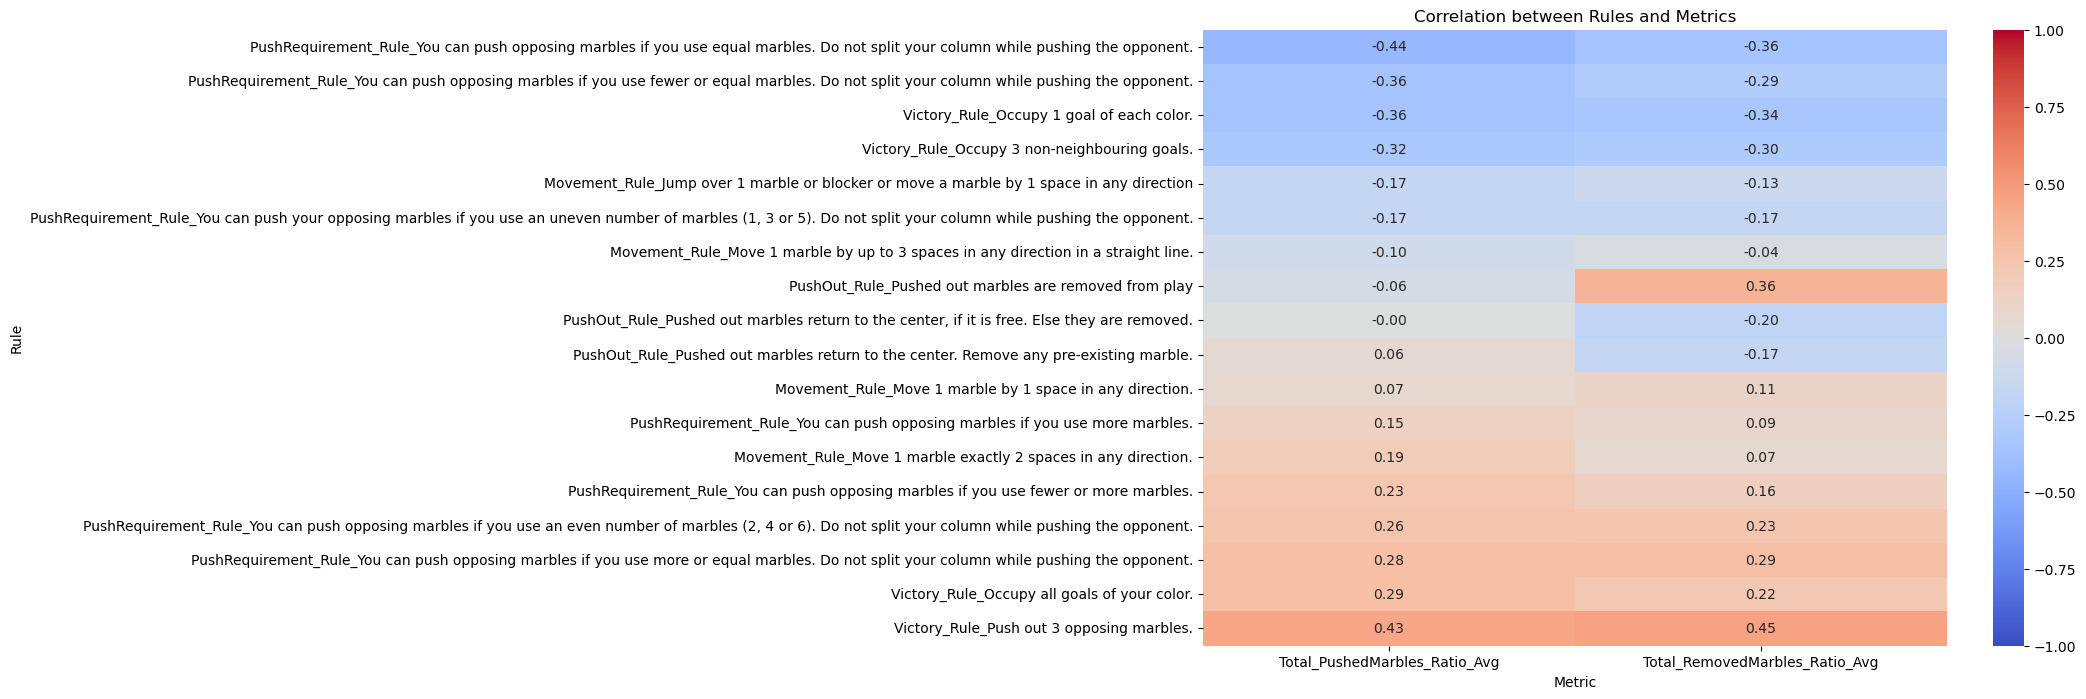

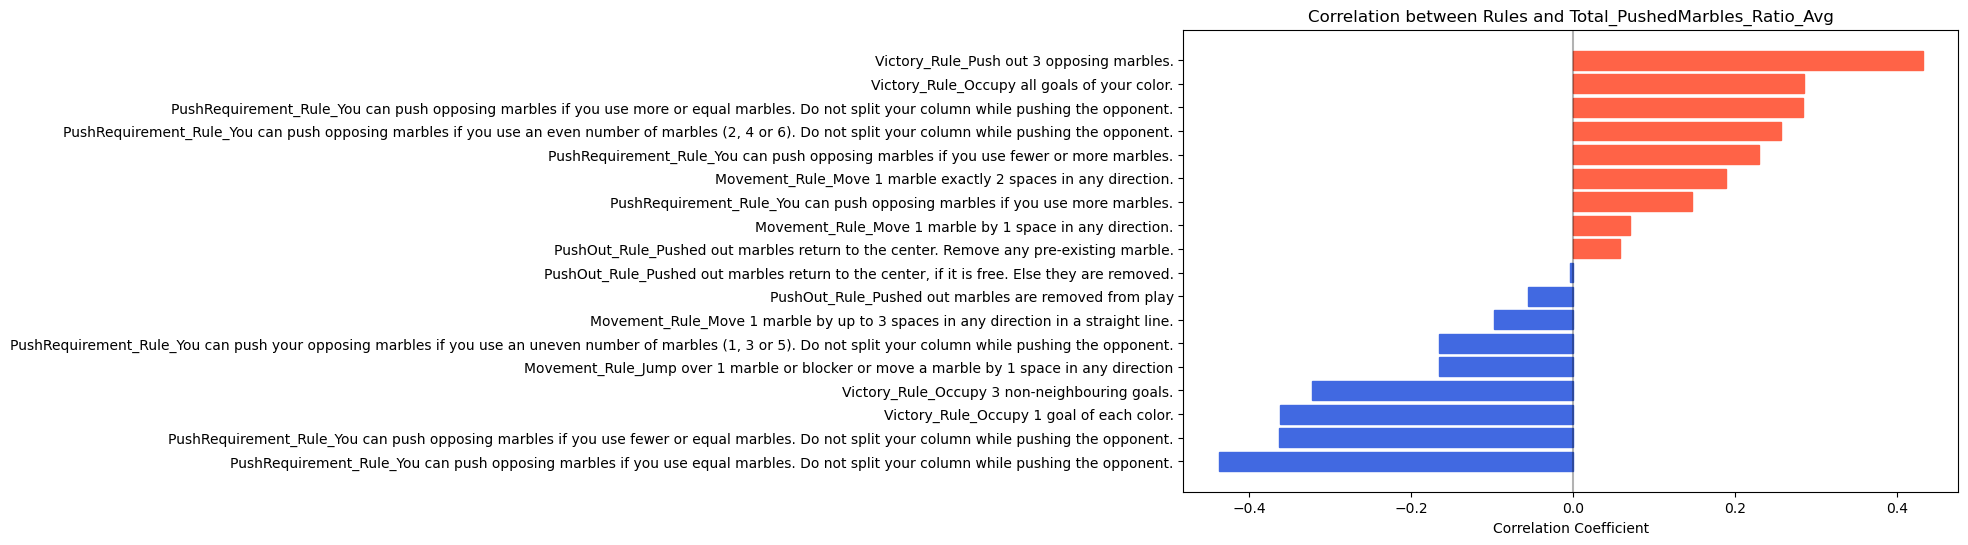

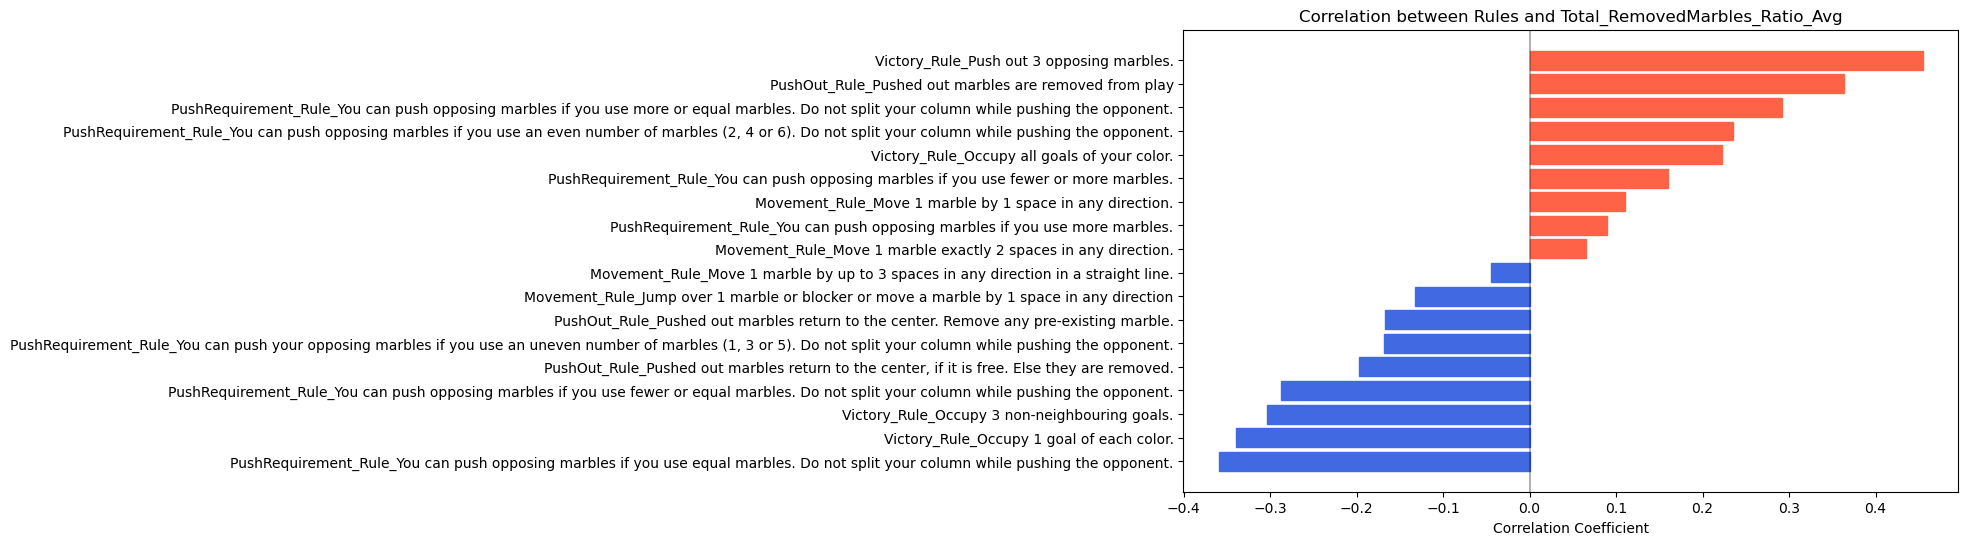

In [49]:
# Assistant
# First, prepare the data for correlation analysis
# Let's use a more focused approach with fewer rules and metrics to make the visualization readable

# Select the most important rules and metrics
rule_columns = ['Setup_Rule', 'Movement_Rule', 'Push_Rule', 'PushOut_Rule', 'PushRequirement_Rule', 'Victory_Rule']
metric_columns = ['Total_PushedMarbles_Ratio_Avg', 'Total_RemovedMarbles_Ratio_Avg']

# Create an empty list to store correlation results
all_correlations = []

# Calculate correlations for each rule and metric
for rule in rule_columns:
    for metric in metric_columns:
        # Get unique values for this rule
        unique_values = marbles_per_setup[rule].unique()
        
        # Skip rules with only one unique value (constant)
        if len(unique_values) <= 1:
            print(f"Skipping {rule} - only has one unique value")
            continue
            
        # For each unique value of the rule
        for value in unique_values:
            # Create a binary indicator for this rule value
            is_rule_value = (marbles_per_setup[rule] == value).astype(int)
            
            # Calculate correlation with the metric
            # Handle potential NaN values
            valid_data = ~(is_rule_value.isna() | marbles_per_setup[metric].isna())
            if valid_data.sum() > 1:  # Need at least 2 points for correlation
                corr = is_rule_value[valid_data].corr(marbles_per_setup[metric][valid_data])
                if not np.isnan(corr):  # Only add if correlation is valid
                    rule_label = f"{rule}_{value}"
                    all_correlations.append({
                        'Rule': rule_label,
                        'Metric': metric,
                        'Correlation': corr
                    })

# Convert to DataFrame
all_correlations_df = pd.DataFrame(all_correlations)

# Check if we have any correlations
if all_correlations_df.empty:
    print("No valid correlations found. Check your data for constant values or NaNs.")
else:
    # Create the pivot table
    pivot_corr = all_correlations_df.pivot(index='Rule', columns='Metric', values='Correlation')
    
    # Sort by correlation with Total_PushedMarbles_Ratio_Avg if it exists
    if 'Total_PushedMarbles_Ratio_Avg' in pivot_corr.columns:
        pivot_corr = pivot_corr.sort_values(by='Total_PushedMarbles_Ratio_Avg')
    
    # If there are too many rules, limit to the top N with strongest correlations
    if len(pivot_corr) > 20:
        print(f"Limiting visualization to top 20 rules with strongest correlations")
        # Get absolute values for sorting
        abs_corr = pivot_corr.abs().max(axis=1).sort_values(ascending=False)
        top_rules = abs_corr.head(20).index
        pivot_corr = pivot_corr.loc[top_rules]
    
    # Visualize the correlations
    plt.figure(figsize=(12, max(8, len(pivot_corr) * 0.4)))  # Adjust height based on number of rules
    ax = sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation between Rules and Metrics')
    
    # Rotate y-axis labels for better readability
    plt.yticks(rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Create a separate bar plot for each metric
    for metric in pivot_corr.columns:
        plt.figure(figsize=(10, max(6, len(pivot_corr) * 0.3)))
        
        # Sort by correlation value
        sorted_data = pivot_corr.sort_values(by=metric)[metric]
        
        # Create bar plot
        bars = plt.barh(sorted_data.index, sorted_data.values)
        
        # Color bars based on positive/negative correlation
        for i, bar in enumerate(bars):
            if sorted_data.values[i] < 0:
                bar.set_color('royalblue')
            else:
                bar.set_color('tomato')
        
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.title(f'Correlation between Rules and {metric}')
        plt.xlabel('Correlation Coefficient')
        plt.tight_layout()
    
    plt.show()

Skipping Setup_Rule - only has one unique value
Skipping Setup_Rule - only has one unique value
Skipping Push_Rule - only has one unique value
Skipping Push_Rule - only has one unique value


C:\Users\Joshua\AppData\Local\Temp\ipykernel_3944\2074675323.py:72: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Joshua\AppData\Local\Temp\ipykernel_3944\2074675323.py:94: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


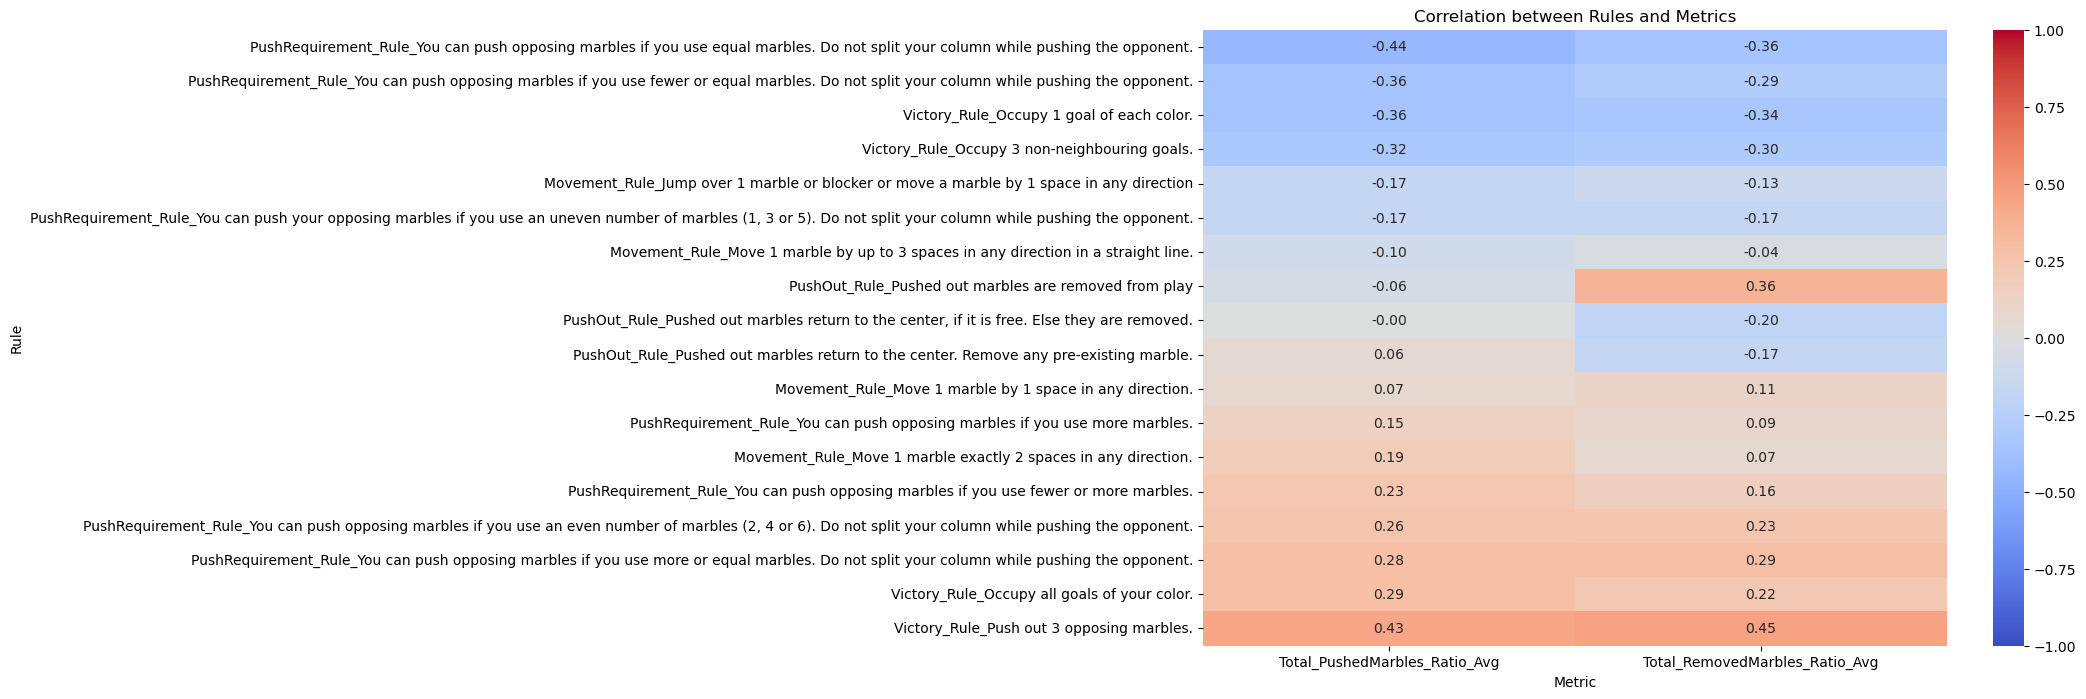

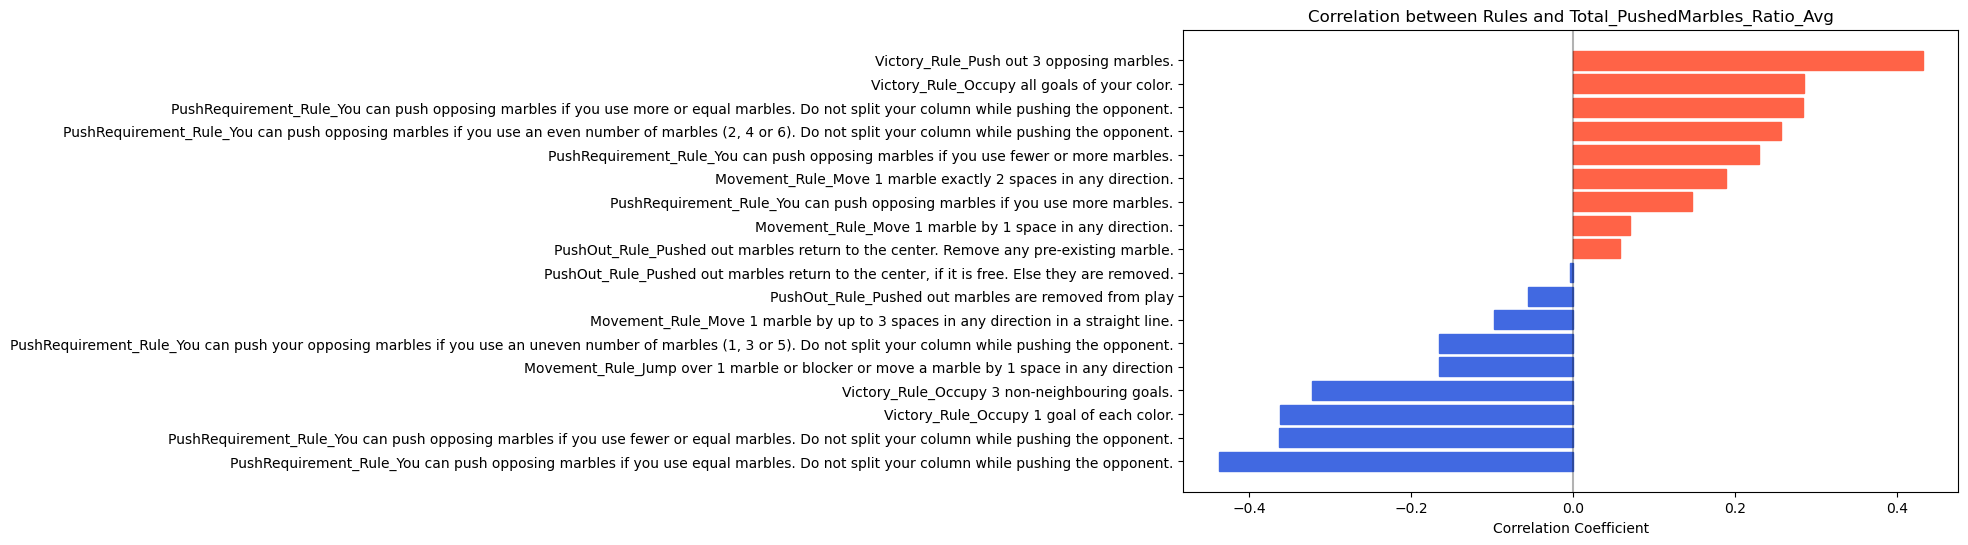

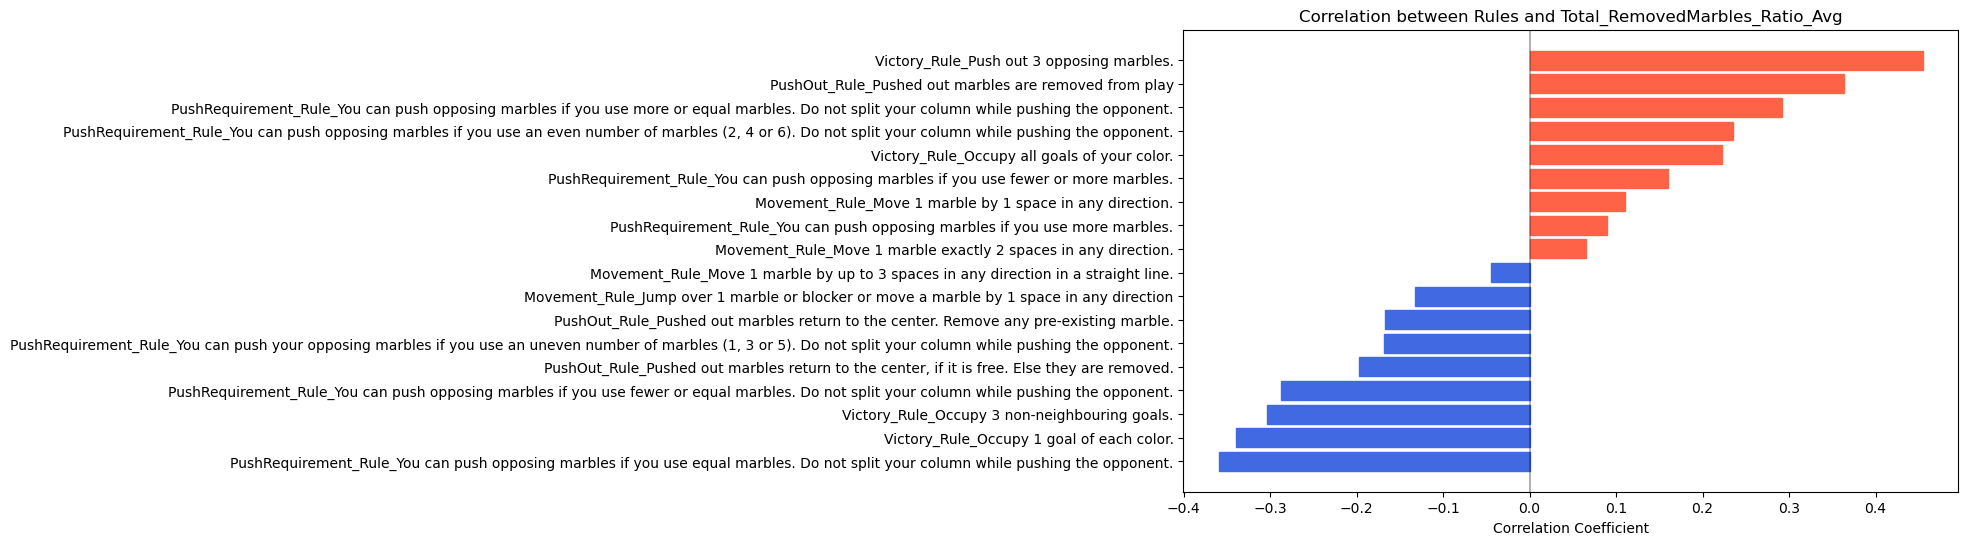

In [63]:
# Assistant
# First, prepare the data for correlation analysis
# Let's use a more focused approach with fewer rules and metrics to make the visualization readable

# Select the most important rules and metrics
rule_columns = ['Setup_Rule', 'Movement_Rule', 'Push_Rule', 'PushOut_Rule', 'PushRequirement_Rule', 'Victory_Rule']
metric_columns = ['Total_PushedMarbles_Ratio_Avg', 'Total_RemovedMarbles_Ratio_Avg']

# Create an empty list to store correlation results
all_correlations = []

# Calculate correlations for each rule and metric
for rule in rule_columns:
    for metric in metric_columns:
        # Get unique values for this rule
        unique_values = marbles_per_setup[rule].unique()
        
        # Skip rules with only one unique value (constant)
        if len(unique_values) <= 1:
            print(f"Skipping {rule} - only has one unique value")
            continue
            
        # For each unique value of the rule
        for value in unique_values:
            # Create a binary indicator for this rule value
            is_rule_value = (marbles_per_setup[rule] == value).astype(int)
            
            # Calculate correlation with the metric
            # Handle potential NaN values
            valid_data = ~(is_rule_value.isna() | marbles_per_setup[metric].isna())
            if valid_data.sum() > 1:  # Need at least 2 points for correlation
                corr = is_rule_value[valid_data].corr(marbles_per_setup[metric][valid_data])
                if not np.isnan(corr):  # Only add if correlation is valid
                    rule_label = f"{rule}_{value}"
                    all_correlations.append({
                        'Rule': rule_label,
                        'Metric': metric,
                        'Correlation': corr
                    })

# Convert to DataFrame
all_correlations_df = pd.DataFrame(all_correlations)

# Check if we have any correlations
if all_correlations_df.empty:
    print("No valid correlations found. Check your data for constant values or NaNs.")
else:
    # Create the pivot table
    pivot_corr = all_correlations_df.pivot(index='Rule', columns='Metric', values='Correlation')
    
    # Sort by correlation with Total_PushedMarbles_Ratio_Avg if it exists
    if 'Total_PushedMarbles_Ratio_Avg' in pivot_corr.columns:
        pivot_corr = pivot_corr.sort_values(by='Total_PushedMarbles_Ratio_Avg')
    
    # If there are too many rules, limit to the top N with strongest correlations
    if len(pivot_corr) > 20:
        print(f"Limiting visualization to top 20 rules with strongest correlations")
        # Get absolute values for sorting
        abs_corr = pivot_corr.abs().max(axis=1).sort_values(ascending=False)
        top_rules = abs_corr.head(20).index
        pivot_corr = pivot_corr.loc[top_rules]
    
    # Visualize the correlations
    plt.figure(figsize=(12, max(8, len(pivot_corr) * 0.4)))  # Adjust height based on number of rules
    ax = sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation between Rules and Metrics')
    
    # Rotate y-axis labels for better readability
    plt.yticks(rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Create a separate bar plot for each metric
    for metric in pivot_corr.columns:
        plt.figure(figsize=(10, max(6, len(pivot_corr) * 0.3)))
        
        # Sort by correlation value
        sorted_data = pivot_corr.sort_values(by=metric)[metric]
        
        # Create bar plot
        bars = plt.barh(sorted_data.index, sorted_data.values)
        
        # Color bars based on positive/negative correlation
        for i, bar in enumerate(bars):
            if sorted_data.values[i] < 0:
                bar.set_color('royalblue')
            else:
                bar.set_color('tomato')
        
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.title(f'Correlation between Rules and {metric}')
        plt.xlabel('Correlation Coefficient')
        plt.tight_layout()
    
    plt.show()

# User
now export these plots as images and the table data as csv file

In [68]:
import os

# Get the directory path from the file path
output_dir = os.path.dirname(r"C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\GAME_OVER.csv")
print(f"Exporting files to: {output_dir}")

# First, prepare the data for correlation analysis
# Let's use a more focused approach with fewer rules and metrics to make the visualization readable

# Select the most important rules and metrics
rule_columns = ['Setup_Rule', 'Movement_Rule', 'Push_Rule', 'PushOut_Rule', 'PushRequirement_Rule', 'Victory_Rule']
metric_columns = ['Total_PushedMarbles_Ratio_Avg', 'Total_RemovedMarbles_Ratio_Avg']

# Create an empty list to store correlation results
all_correlations = []

# Calculate correlations for each rule and metric
for rule in rule_columns:
    for metric in metric_columns:
        # Get unique values for this rule
        unique_values = marbles_per_setup[rule].unique()
        
        # Skip rules with only one unique value (constant)
        if len(unique_values) <= 1:
            print(f"Skipping {rule} - only has one unique value")
            continue
            
        # For each unique value of the rule
        for value in unique_values:
            # Create a binary indicator for this rule value
            is_rule_value = (marbles_per_setup[rule] == value).astype(int)
            
            # Calculate correlation with the metric
            # Handle potential NaN values
            valid_data = ~(is_rule_value.isna() | marbles_per_setup[metric].isna())
            if valid_data.sum() > 1:  # Need at least 2 points for correlation
                corr = is_rule_value[valid_data].corr(marbles_per_setup[metric][valid_data])
                if not np.isnan(corr):  # Only add if correlation is valid
                    rule_label = f"{rule}_{value}"
                    all_correlations.append({
                        'Rule': rule_label,
                        'Metric': metric,
                        'Correlation': corr
                    })

# Convert to DataFrame
all_correlations_df = pd.DataFrame(all_correlations)

# Export the correlation data to CSV
csv_path = os.path.join(output_dir, 'rule_metric_correlations.csv')
all_correlations_df.to_csv(csv_path, index=False)
print(f"Correlation data exported to '{csv_path}'")

# Check if we have any correlations
if all_correlations_df.empty:
    print("No valid correlations found. Check your data for constant values or NaNs.")
else:
    # Create the pivot table
    pivot_corr = all_correlations_df.pivot(index='Rule', columns='Metric', values='Correlation')
    
    # Export pivot table to CSV
    pivot_csv_path = os.path.join(output_dir, 'correlation_pivot_table.csv')
    pivot_corr.to_csv(pivot_csv_path)
    print(f"Pivot table exported to '{pivot_csv_path}'")
    
    # Sort by correlation with Total_PushedMarbles_Ratio_Avg if it exists
    if 'Total_PushedMarbles_Ratio_Avg' in pivot_corr.columns:
        pivot_corr = pivot_corr.sort_values(by='Total_PushedMarbles_Ratio_Avg')
    
    # If there are too many rules, limit to the top N with strongest correlations
    if len(pivot_corr) > 20:
        print(f"Limiting visualization to top 20 rules with strongest correlations")
        # Get absolute values for sorting
        abs_corr = pivot_corr.abs().max(axis=1).sort_values(ascending=False)
        top_rules = abs_corr.head(20).index
        pivot_corr = pivot_corr.loc[top_rules]
    
    # Visualize the correlations
    plt.figure(figsize=(12, max(8, len(pivot_corr) * 0.4)))  # Adjust height based on number of rules
    ax = sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation between Rules and Metrics')
    
    # Rotate y-axis labels for better readability
    plt.yticks(rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the heatmap
    heatmap_path = os.path.join(output_dir, 'correlation_heatmap.png')
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved as '{heatmap_path}'")
    
    # Create a separate bar plot for each metric
    for metric in pivot_corr.columns:
        plt.figure(figsize=(10, max(6, len(pivot_corr) * 0.3)))
        
        # Sort by correlation value
        sorted_data = pivot_corr.sort_values(by=metric)[metric]
        
        # Create bar plot
        bars = plt.barh(sorted_data.index, sorted_data.values)
        
        # Color bars based on positive/negative correlation
        for i, bar in enumerate(bars):
            if sorted_data.values[i] < 0:
                bar.set_color('royalblue')
            else:
                bar.set_color('tomato')
        
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.title(f'Correlation between Rules and {metric}')
        plt.xlabel('Correlation Coefficient')
        plt.tight_layout()
        
        # Save the bar plot
        barplot_path = os.path.join(output_dir, f'correlation_barplot_{metric}.png')
        plt.savefig(barplot_path, dpi=300, bbox_inches='tight')
        print(f"Bar plot saved as '{barplot_path}'")
    
    plt.close('all')  # Close all figures to free memory

Exporting files to: C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment
Skipping Setup_Rule - only has one unique value
Skipping Setup_Rule - only has one unique value
Skipping Push_Rule - only has one unique value
Skipping Push_Rule - only has one unique value
Correlation data exported to 'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\rule_metric_correlations.csv'
Pivot table exported to 'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\correlation_pivot_table.csv'


C:\Users\Joshua\AppData\Local\Temp\ipykernel_3944\1124143877.py:87: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Heatmap saved as 'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\correlation_heatmap.png'


C:\Users\Joshua\AppData\Local\Temp\ipykernel_3944\1124143877.py:114: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Bar plot saved as 'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\correlation_barplot_Total_PushedMarbles_Ratio_Avg.png'
Bar plot saved as 'C:\Users\Joshua\Documents\GitSources\TabletopGamesWIP\MMExperiment\correlation_barplot_Total_RemovedMarbles_Ratio_Avg.png'
